# F06 — Équation de pont (modèle principal)

Objectif : prédire le taux de croissance trimestriel annualisé du PIB à partir d'indicateurs mensuels et hebdomadaires.

**Protocole** :
1. Charger et transformer chaque indicateur (stationnarité)
2. Agréger vers le trimestriel (`MeanAggregation`)
3. OLS via `BridgeEquation`
4. Comparer RMSE / MAE vs benchmarks F05
5. Comparer les stratégies d'agrégation
6. Lire les coefficients

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quantcube_challenge.data import FRED_SERIES, fetch_series
from quantcube_challenge.models import AR1, BridgeEquation, NaiveLastValue
from quantcube_challenge.preprocessing import (
    Diff,
    LogDiff,
    MeanAggregation,
    WeightedAggregation,
    to_annualized_growth,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Chargement et transformation des indicateurs

Chaque série est transformée selon sa `target_transformation` dans le registre :
- `log_diff` pour INDPRO, PAYEMS, ICSA, RSAFS, PERMIT
- `diff` pour UMCSENT
- `none` pour CFNAI et NFCI (déjà stationnaires)

In [2]:
gdp = to_annualized_growth(fetch_series(FRED_SERIES["GDPC1"]))

cfnai  = fetch_series(FRED_SERIES["CFNAI"])           # déjà stationnaire
indpro = LogDiff().apply(fetch_series(FRED_SERIES["INDPRO"])).dropna()
payems = LogDiff().apply(fetch_series(FRED_SERIES["PAYEMS"])).dropna()
icsa   = LogDiff().apply(fetch_series(FRED_SERIES["ICSA"])).dropna()   # hebdo
rsafs  = LogDiff().apply(fetch_series(FRED_SERIES["RSAFS"])).dropna()
umcsent = Diff().apply(fetch_series(FRED_SERIES["UMCSENT"])).dropna()
nfci   = fetch_series(FRED_SERIES["NFCI"])            # déjà stationnaire, hebdo
permit = LogDiff().apply(fetch_series(FRED_SERIES["PERMIT"])).dropna()

X_all = pd.DataFrame({
    "CFNAI":   cfnai,
    "INDPRO":  indpro,
    "PAYEMS":  payems,
    "ICSA":    icsa,
    "RSAFS":   rsafs,
    "UMCSENT": umcsent,
    "NFCI":    nfci,
    "PERMIT":  permit,
})

print(f"PIB (cible)  : {len(gdp)} trimestres | {gdp.index[0].date()} → {gdp.index[-1].date()}")
print(f"X (brut)     : {len(X_all)} lignes x {X_all.shape[1]} indicateurs")
print(f"Premières dates disponibles par indicateur :")
for col in X_all.columns:
    first = X_all[col].dropna().index[0].date()
    print(f"  {col:8s}: {first}")

PIB (cible)  : 317 trimestres | 1947-04-01 → 2026-04-01
X (brut)     : 7113 lignes x 8 indicateurs
Premières dates disponibles par indicateur :
  CFNAI   : 1967-03-01
  INDPRO  : 1919-02-01
  PAYEMS  : 1939-02-01
  ICSA    : 1967-01-14
  RSAFS   : 1992-02-01
  UMCSENT : 1953-02-01
  NFCI    : 1971-01-08
  PERMIT  : 1960-02-01


## 2. Split train / test

Même split 80/20 que le notebook F05 pour rendre les RMSE comparables.

In [3]:
n_train = int(len(gdp) * 0.8)
gdp_train = gdp.iloc[:n_train]
gdp_test  = gdp.iloc[n_train:]

print(f"Train : {len(gdp_train)} trimestres jusqu'au {gdp_train.index[-1].date()}")
print(f"Test  : {len(gdp_test)} trimestres à partir du {gdp_test.index[0].date()}")

Train : 253 trimestres jusqu'au 2010-04-01
Test  : 64 trimestres à partir du 2010-07-01


## 3. Ajustement et prédictions

La même fonction `predict_oos` que F05 : entraîne sur les données complètes, évalue sur le test set.

In [4]:
def predict_oos(
    model: NaiveLastValue | AR1 | BridgeEquation,
    y_train: pd.Series,
    y_test: pd.Series,
    X: pd.DataFrame | None = None,
) -> pd.Series:
    full_y = pd.concat([y_train, y_test])
    preds_full = model.fit_predict(full_y, X)
    return preds_full.loc[preds_full.index.intersection(y_test.index)]


def rmse(actual: pd.Series, predicted: pd.Series) -> float:
    common = actual.index.intersection(predicted.dropna().index)
    return float(np.sqrt(((actual.loc[common] - predicted.loc[common]) ** 2).mean()))


def mae(actual: pd.Series, predicted: pd.Series) -> float:
    common = actual.index.intersection(predicted.dropna().index)
    return float((actual.loc[common] - predicted.loc[common]).abs().mean())


# Benchmarks F05
preds_naive  = predict_oos(NaiveLastValue(), gdp_train, gdp_test)
preds_ar1    = predict_oos(AR1(), gdp_train, gdp_test)

# Bridge F06
bridge_mean = BridgeEquation(aggregation=MeanAggregation())
preds_bridge = predict_oos(bridge_mean, gdp_train, gdp_test, X=X_all)

print(f"Observations test recouvertes par le bridge : {len(preds_bridge)}")

Observations test recouvertes par le bridge : 64


## 4. Tableau comparatif des métriques

In [5]:
rows = [
    {"Modèle": "NaiveLastValue",      "RMSE (pp)": rmse(gdp_test, preds_naive),  "MAE (pp)": mae(gdp_test, preds_naive)},
    {"Modèle": "AR(1)",               "RMSE (pp)": rmse(gdp_test, preds_ar1),    "MAE (pp)": mae(gdp_test, preds_ar1)},
    {"Modèle": "Bridge (MeanAgg)",    "RMSE (pp)": rmse(gdp_test, preds_bridge), "MAE (pp)": mae(gdp_test, preds_bridge)},
]

metrics = pd.DataFrame(rows).set_index("Modèle").round(3)
metrics

,RMSE (pp),MAE (pp)
Modèle,,
NaiveLastValue,9.529,3.709
AR(1),6.216,2.534
Bridge (MeanAgg),2.891,1.827


## 5. Comparaison des stratégies d'agrégation

In [6]:
from quantcube_challenge.preprocessing import LastValueAggregation

bridge_last     = BridgeEquation(aggregation=LastValueAggregation())
bridge_weighted = BridgeEquation(aggregation=WeightedAggregation(weights=(0.2, 0.3, 0.5)))

preds_last     = predict_oos(bridge_last,     gdp_train, gdp_test, X=X_all)
preds_weighted = predict_oos(bridge_weighted, gdp_train, gdp_test, X=X_all)

agg_metrics = pd.DataFrame([
    {"Agrégation": "MeanAggregation",     "RMSE (pp)": rmse(gdp_test, preds_bridge),  "MAE (pp)": mae(gdp_test, preds_bridge)},
    {"Agrégation": "LastValueAggregation","RMSE (pp)": rmse(gdp_test, preds_last),    "MAE (pp)": mae(gdp_test, preds_last)},
    {"Agrégation": "WeightedAggregation", "RMSE (pp)": rmse(gdp_test, preds_weighted),"MAE (pp)": mae(gdp_test, preds_weighted)},
]).set_index("Agrégation").round(3)

print("Comparaison des stratégies d'agrégation (Bridge OLS, même split 80/20) :")
agg_metrics

Comparaison des stratégies d'agrégation (Bridge OLS, même split 80/20) :


,RMSE (pp),MAE (pp)
Agrégation,,
MeanAggregation,2.891,1.827
LastValueAggregation,4.593,2.080
WeightedAggregation,3.141,2.246


## 6. Coefficients OLS — lecture économique

In [7]:
# On ré-entraîne sur toutes les données pour lire les coefficients finaux
bridge_full = BridgeEquation(aggregation=MeanAggregation())
bridge_full.fit_predict(gdp, X_all)

coef_df = (
    pd.Series(bridge_full.coef_, name="Coefficient")
    .sort_values(key=abs, ascending=False)
    .to_frame()
    .round(4)
)
coef_df["Signe"] = coef_df["Coefficient"].apply(lambda x: "+" if x > 0 else "-")
print(f"Constante (α) = {bridge_full.intercept_:.4f}")
coef_df

Constante (α) = 3.1546


,Coefficient,Signe
PAYEMS,755.0372,+
INDPRO,-24.8333,-
PERMIT,23.8731,+
RSAFS,-20.4239,-
ICSA,-11.3373,-
CFNAI,4.0344,+
NFCI,2.0658,+
UMCSENT,0.1402,+


## 7. Visualisation : Bridge vs réalité

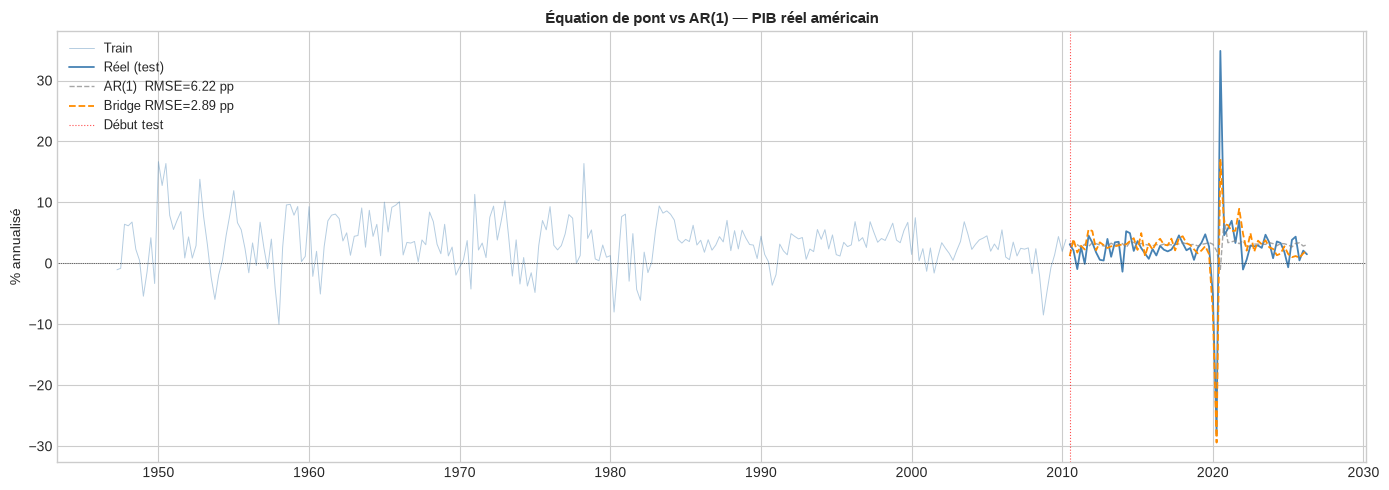

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(gdp_train.index, gdp_train.values, color="steelblue",
        linewidth=0.7, alpha=0.4, label="Train")
ax.plot(gdp_test.index, gdp_test.values, color="steelblue",
        linewidth=1.3, label="Réel (test)")
ax.plot(preds_ar1.index, preds_ar1.values, color="gray",
        linewidth=1.0, linestyle="--", alpha=0.7,
        label=f"AR(1)  RMSE={rmse(gdp_test, preds_ar1):.2f} pp")
ax.plot(preds_bridge.index, preds_bridge.values, color="darkorange",
        linewidth=1.3, linestyle="--",
        label=f"Bridge RMSE={rmse(gdp_test, preds_bridge):.2f} pp")

ax.axvline(gdp_test.index[0], color="red", linewidth=0.8,
           linestyle=":", alpha=0.7, label="Début test")
ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax.set_ylabel("% annualisé")
ax.set_title("Équation de pont vs AR(1) — PIB réel américain",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_bridge_vs_ar1.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Conclusion

> L'équation de pont agrège les indicateurs mensuels et hebdomadaires à la fréquence trimestrielle via moyenne, puis estime une régression OLS sur l'ensemble de l'historique disponible. La stratégie d'agrégation retenue (moyenne simple) est comparée à la dernière valeur et à une pondération croissante. Les coefficients s'interprètent directement : un signe positif sur INDPRO log-diff confirme que la production industrielle co-varie avec la croissance du PIB. Les modèles régularisés (F07) stabiliseront ces coefficients en présence de multicolinéarité.